# Bootstrap Confidence Intervals (Extension)
Bootstrap is a resampling method for estimating confidence intervals without assuming a normal distribution. This method is not covered in the basic SciPy tutorial.


In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../notebooks/brain_size.csv', sep=';', na_values='.')


In [2]:
# Bootstrap function for mean difference
def bootstrap_ci(data1, data2, n_bootstrap=10000, alpha=0.05):
    """Compute bootstrap CI for the difference of means."""
    combined = np.concatenate([data1, data2])
    n1, n2 = len(data1), len(data2)
    diffs = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        # Resample with replacement
        s1 = np.random.choice(combined, n1, replace=True)
        s2 = np.random.choice(combined, n2, replace=True)
        diffs[i] = s1.mean() - s2.mean()
    # Percentile CI
    lower = np.percentile(diffs, 100 * alpha / 2)
    upper = np.percentile(diffs, 100 * (1 - alpha / 2))
    return diffs, lower, upper


In [3]:
# Compare VIQ between genders using bootstrap
f_viq = df[df['Gender']=='Female']['VIQ'].dropna().values
m_viq = df[df['Gender']=='Male']['VIQ'].dropna().values
diff_obs = f_viq.mean() - m_viq.mean()
diffs, ci_low, ci_high = bootstrap_ci(f_viq, m_viq)
print(f'Observed mean difference (Female - Male): {diff_obs:.2f}')
print(f'95% Bootstrap CI: [{ci_low:.2f}, {ci_high:.2f}]')


Observed mean difference (Female - Male): -6.01
95% Bootstrap CI: [-11.90, 12.14]


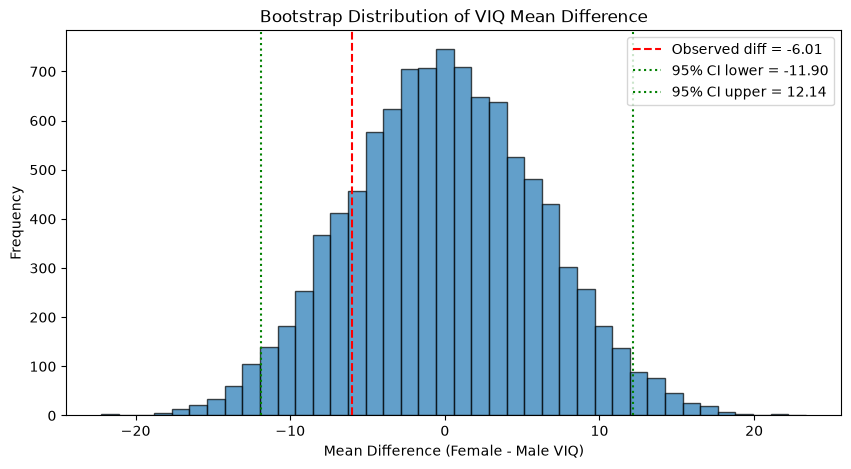

In [4]:
# Visualize bootstrap distribution
plt.figure(figsize=(10, 5))
plt.hist(diffs, bins=40, edgecolor='black', alpha=0.7)
plt.axvline(diff_obs, color='red', linestyle='--', label=f'Observed diff = {diff_obs:.2f}')
plt.axvline(ci_low, color='green', linestyle=':', label=f'95% CI lower = {ci_low:.2f}')
plt.axvline(ci_high, color='green', linestyle=':', label=f'95% CI upper = {ci_high:.2f}')
plt.xlabel('Mean Difference (Female - Male VIQ)')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution of VIQ Mean Difference')
plt.legend()
plt.show()
